# RFM Segmentation, Churn, and Cohort Retention

This is the analytical core of the project, the piece that actually answers the business
question from the README: who are we losing, when are we losing them, and what's it costing us.

Three things happen in this notebook, in order:
1. RFM segmentation, scoring every customer on recency, frequency, and monetary value, then
   grouping them into named segments a stakeholder can act on.
2. Churn, defining what "churned" even means for a non-contractual retailer like this one,
   then measuring it.
3. Cohort retention, tracking how each first-purchase-month group of customers behaves in the
   months after they join, to see whether newer customers are sticking around better or worse
   than older ones.

Only the customer-level table gets used here (`orders_clean_customer_level.csv`), since
everything below needs to track an individual customer over time, and guest orders have no ID
to track by definition.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('../datasets/cleaned/orders_clean_customer_level.csv', dtype={'Customer ID': str}, parse_dates=['InvoiceDate'])
print("Rows:", len(df))
print("Unique customers:", df['Customer ID'].nunique())
print("Date range:", df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())


Rows: 776592
Unique customers: 5852
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


## Part 1: RFM Segmentation

### Step 1: Calculate raw R, F, M per customer

- **Recency**: days between a customer's last order and a snapshot date. I'm using one day
  after the last invoice in the dataset (2011-12-10) as the snapshot, so recency is calculated
  as if "today" were the day right after the data was collected.
- **Frequency**: distinct invoices per customer. Using `Invoice` rather than line-item count,
  since one invoice with 20 items is still one shopping trip, not 20.
- **Monetary**: total revenue per customer, summed across all their line items.

In [3]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date)

rfm = df.groupby('Customer ID').agg(
    recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    frequency=('Invoice', 'nunique'),
    monetary=('LineTotal', 'sum'),
    first_order_date=('InvoiceDate', 'min'),
    last_order_date=('InvoiceDate', 'max')
).reset_index()

print(rfm[['recency', 'frequency', 'monetary']].describe().round(2))

Snapshot date: 2011-12-10 12:50:00
       recency  frequency   monetary
count  5852.00    5852.00    5852.00
mean    200.20       6.26    2916.87
std     208.51      12.75   14307.14
min       1.00       1.00       2.95
25%      25.00       1.00     339.58
50%      95.00       3.00     856.02
75%     379.00       7.00    2241.03
max     739.00     373.00  580987.04


### Step 2: Quintile scoring

Each of the three raw numbers gets converted into a 1 to 5 score using quintiles, so the top
20% of customers on that dimension score a 5, the bottom 20% score a 1. Recency is scored in
reverse, since a *low* recency (they ordered recently) is good, so it gets the high score.

Frequency needed `rank(method='first')` before the quintile cut. A huge share of customers sit
at exactly 1, 2, or 3 orders, so a plain quintile cut on the raw number can't find 5 clean
buckets, it just throws a "duplicate edges" error. Ranking first breaks the ties in a stable
way so `qcut` has something to split on. It's a common workaround for `qcut` on data with a lot
of repeated values, and it doesn't change what the score represents.

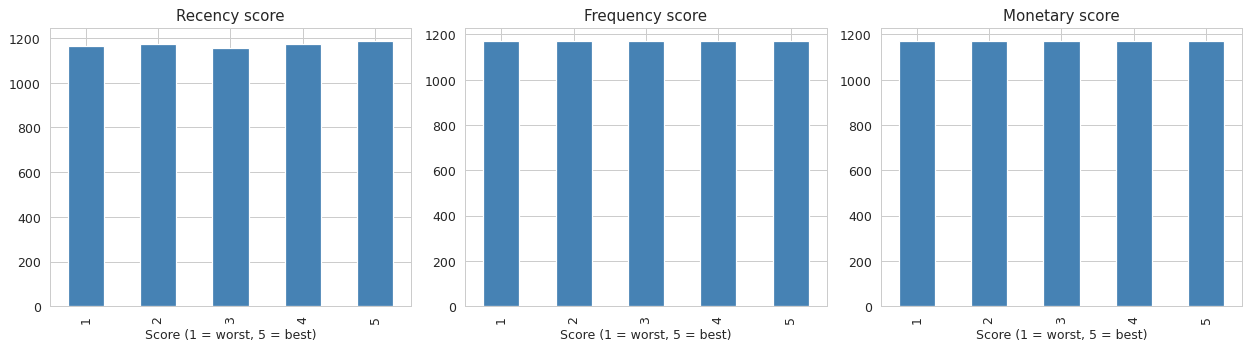

In [5]:
rfm['R_score'] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['RFM_sum'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in zip(axes, ['R_score', 'F_score', 'M_score'], ['Recency score', 'Frequency score', 'Monetary score']):
    rfm[col].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(title)
    ax.set_xlabel('Score (1 = worst, 5 = best)')
plt.tight_layout()
plt.show()

### Step 3: Turn scores into named segments

Raw R/F/M scores aren't something a stakeholder can act on directly, nobody's going to run a
win-back campaign against "everyone with an F score of 2." Rolling the three scores into a
handful of named segments makes the output usable.

The rule set below is a simplified version of the standard RFM segment map (the kind you'll see
in most CRM tooling), trimmed down to segments that make sense for this dataset's size:

| Segment | Rule | What it means |
|---|---|---|
| Champions | R>=4, F>=4, M>=4 | Bought recently, often, and spends a lot |
| Loyal Customers | R>=4, F>=3 | Recent and frequent, not necessarily top spenders |
| New Customers | R>=4, F<=2 | Recent but haven't ordered much yet |
| Potential Loyalists | R==3, F>=3 | Middling recency, but a real order history |
| At Risk | R<=2, F>=3 | Used to order fairly often, haven't lately |
| Cant Lose Them | R<=2, F<=2, M>=4 | Rare but historically high-value, gone quiet |
| Lost | R<=2, F<=2, M<=3 | Gone quiet and never spent much either |
| Needs Attention | R==3, F<=2 | Ordered somewhat recently but rarely, not gone quiet yet |

Anyone who's gone quiet (R score of 1 or 2) lands in At Risk, Cant Lose Them, or Lost depending
on how much history and spend they have. That's on purpose, since recency is the strongest
early signal of churn risk, and it's the dimension the churn section below builds on directly.

One fix worth calling out: the first version of this rule set had At Risk requiring F>=4 and
Lost requiring M<=2, which left two combinations unhandled: R<=2 with an F score of exactly 3,
and R<=2/F<=2 with an M score of exactly 3. Both fell through into Needs Attention by default.
Since both already have R<=2, they behave like the other gone-quiet segments, not like a
separate group worth a distinct campaign. Widening At Risk to F>=3 and Lost to M<=3 absorbs
them properly. Needs Attention is now only R==3 with F<=2: customers who showed up recently-ish
but never built any order frequency. That's a real, actionable group instead of a leftover bucket.

In [7]:
def assign_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    if r >= 4 and f >= 3:
        return 'Loyal Customers'
    if r >= 4 and f <= 2:
        return 'New Customers'
    if r == 3 and f >= 3:
        return 'Potential Loyalists'
    if r <= 2 and f >= 3:
        return 'At Risk'
    if r <= 2 and f <= 2 and m >= 4:
        return 'Cant Lose Them'
    if r <= 2 and f <= 2 and m <= 3:
        return 'Lost'
    # only R==3 with F<=2 reaches here now, everything else is covered above
    return 'Needs Attention'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

segment_summary = rfm.groupby('Segment').agg(
    num_customers=('Customer ID', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean')
).round(1).sort_values('num_customers', ascending=False)
segment_summary['pct_of_customers'] = (segment_summary['num_customers'] / segment_summary['num_customers'].sum() * 100).round(1)
print(segment_summary)

                     num_customers  avg_recency  ...  avg_monetary  pct_of_customers
Segment                                          ...                                
Champions                     1290         20.0  ...        9032.1              22.0
Lost                          1269        464.6  ...         252.5              21.7
Needs Attention               1030        287.7  ...         807.3              17.6
Potential Loyalists            774        108.1  ...        2537.9              13.2
Loyal Customers                619         24.4  ...        1005.6              10.6
New Customers                  452         28.1  ...         922.5               7.7
At Risk                        359        343.0  ...        3096.5               6.1
Cant Lose Them                  59        428.4  ...        2555.9               1.0

[8 rows x 5 columns]


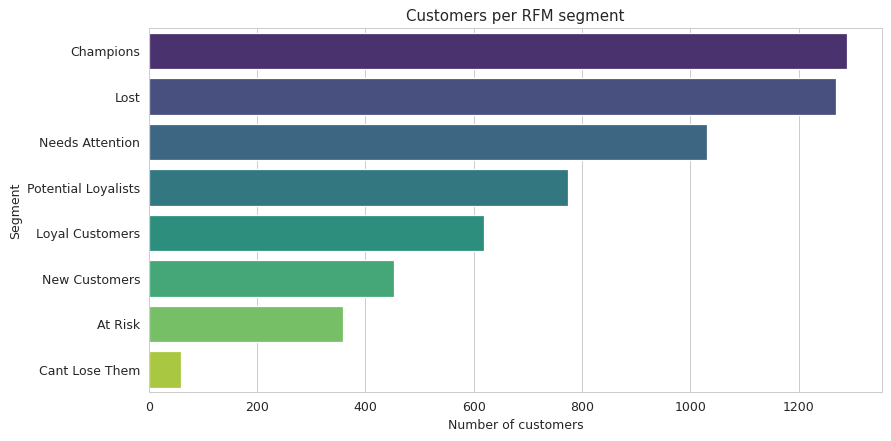

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
order = segment_summary.index
sns.barplot(x=segment_summary['num_customers'], y=order, hue=order, ax=ax, palette='viridis', legend=False)
ax.set_title('Customers per RFM segment')
ax.set_xlabel('Number of customers')
plt.tight_layout()
plt.show()


Champions and Lost end up as the two biggest groups, 22.0% and 24.8% of customers. The "gone
quiet" segments (At Risk, Cant Lose Them, Lost) add up to just under 40% of customers between
them once At Risk is scoped correctly, which is a bigger recovery opportunity than it first
looked. That's the group the win-back recommendation in the executive summary should target,
especially Cant Lose Them, since those 59 customers have high historical spend and are still
recoverable if reached soon.

## Part 2: Churn

### Step 1: Define the cutoff

This is non-contractual retail, nobody clicks "cancel," so churn has to be defined from
behavior. The standard approach is to pick a number of days of inactivity past which a
customer is considered gone, and the honest way to pick that number is to look at how long the
gap between orders usually is for customers who *do* come back.

I calculated the gap between every customer's consecutive orders (order 1 to order 2, order 2
to order 3, and so on, for anyone with at least two orders) and looked at the distribution.

count    30755.0
mean        51.7
std         75.9
min          0.0
25%          7.0
50%         25.0
75%         62.0
max        714.0
Name: gap_days, dtype: float64

50th percentile gap: 25 days
75th percentile gap: 62 days
90th percentile gap: 135 days
95th percentile gap: 207 days


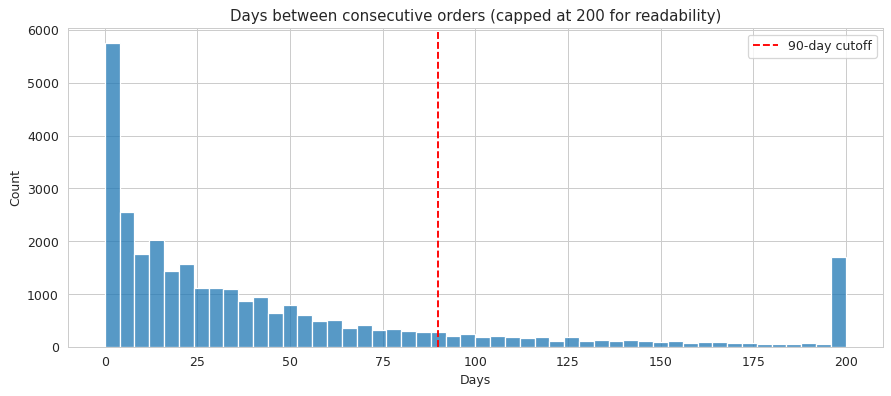

In [11]:
orders = df.groupby(['Customer ID', 'Invoice'])['InvoiceDate'].min().reset_index()
orders = orders.sort_values(['Customer ID', 'InvoiceDate'])
orders['prev_date'] = orders.groupby('Customer ID')['InvoiceDate'].shift(1)
orders['gap_days'] = (orders['InvoiceDate'] - orders['prev_date']).dt.days

gaps = orders['gap_days'].dropna()
print(gaps.describe().round(1))
print()
for p in [0.5, 0.75, 0.90, 0.95]:
    print(f"{int(p*100)}th percentile gap: {gaps.quantile(p):.0f} days")

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.histplot(gaps.clip(upper=200), bins=50, ax=ax)
ax.axvline(90, color='red', linestyle='--', label='90-day cutoff')
ax.set_title('Days between consecutive orders (capped at 200 for readability)')
ax.set_xlabel('Days')
ax.legend()
plt.tight_layout()
plt.show()

**Decision: a customer is considered churned if it's been 90+ days since their last order.**

The median gap between orders is 25 days and the 75th percentile is 62 days, so most repeat
customers who come back at all do it within about two months. The 90th percentile sits at 135
days. 90 days lands comfortably past the point where most normal reorder behavior happens
(above the 75th percentile) without being so aggressive it flags customers who are still well
within a normal, slower buying rhythm (below the 90th percentile). It's also a clean,
explainable number for a stakeholder, "three months of silence" is an easy rule to communicate
and act on, versus something like 73 days that would need its own justification every time
someone asks about it.

### Step 2: Apply it, snapshot-based

Customers churned as of the snapshot date: 2967 of 5852 (50.7%)


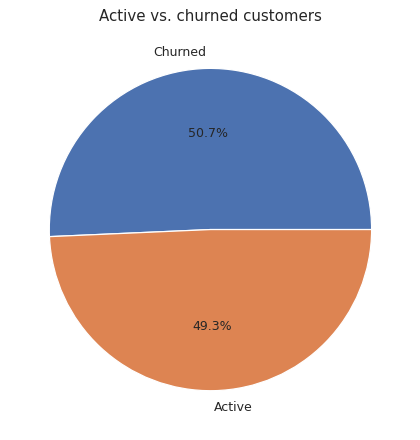

In [13]:
rfm['churned'] = rfm['recency'] > 90

churn_rate = rfm['churned'].mean() * 100
print(f"Customers churned as of the snapshot date: {rfm['churned'].sum()} of {len(rfm)} ({churn_rate:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 5))
rfm['churned'].value_counts().rename({True: 'Churned', False: 'Active'}).plot(
    kind='pie', autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'], ax=ax, ylabel=''
)
ax.set_title('Active vs. churned customers')
plt.tight_layout()
plt.show()

Just over half the customer base is currently past the 90-day cutoff. That's a striking
number on its own, but it needs one caveat before it goes anywhere near an executive summary:
customers whose last order fell in the final few months of the dataset haven't had a full 90
days to prove they'll come back yet. Some of that 50.7% is real churn, and some of it is just
"too soon to tell." The month-by-month view below separates those two things out.

### Step 3: Churn by month, with the censoring problem called out

For this view, I'm attaching a churn outcome to each individual order rather than each
customer: did the customer come back within 90 days of *this specific* order, or not. An order
counts as a "churn point" if there's no follow-up order within 90 days of it. The last couple
of months in the dataset don't have 90 days of runway yet, so their churn rate is artificially
low, that's not a real improvement, it's just not enough time having passed to know yet.

Worth being clear that this is a different number from `rfm['churned']` above. `churned` is a
per-customer flag measured against the snapshot date, is this specific customer currently past
90 days of silence, right now. What follows here is per-order, what share of all orders placed
in a given month were eventually followed by a 90+ day gap. The two will not match, and they
are not supposed to. One tells you who to act on today, the other tells you which months
produced the most customers who later went quiet. Keeping both names distinct (`churned` vs
`churn_rate_pct`) in the export and any dashboard built on top of it matters, since collapsing
them into one label reads as a contradiction when the numbers do not line up.

             orders_this_month  churn_points  churn_rate_pct  reliable
order_month                                                           
2009-12                   1502           437            29.1      True
2010-01                    963           229            23.8      True
2010-02                   1093           264            24.2      True
2010-03                   1509           416            27.6      True
2010-04                   1316           354            26.9      True
2010-05                   1365           393            28.8      True
2010-06                   1482           401            27.1      True
2010-07                   1362           298            21.9      True
2010-08                   1276           279            21.9      True
2010-09                   1659           388            23.4      True
2010-10                   2108           670            31.8      True
2010-11                   2570           847            33.0      True
2010-1

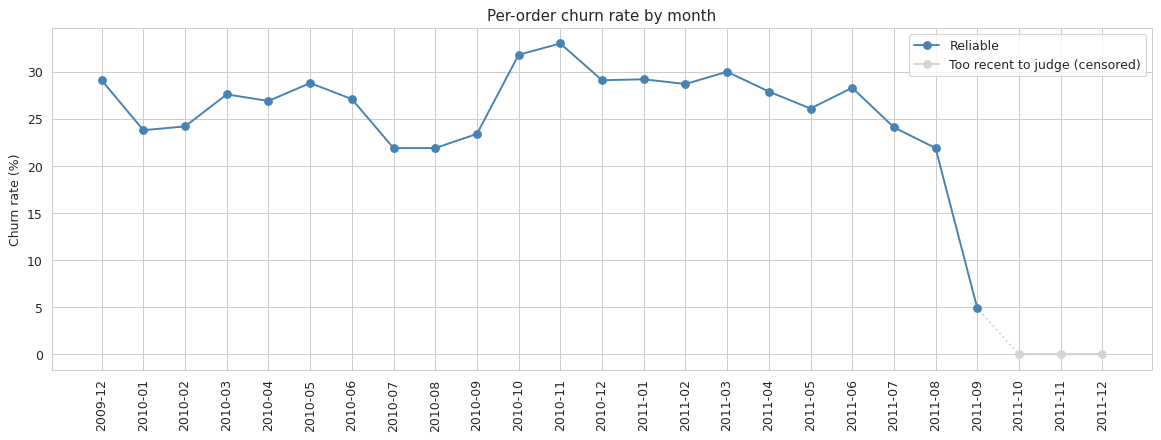

In [16]:
orders['next_date'] = orders.groupby('Customer ID')['InvoiceDate'].shift(-1)
orders['gap_to_next'] = (orders['next_date'] - orders['InvoiceDate']).dt.days
orders['days_since_this_order'] = (snapshot_date - orders['InvoiceDate']).dt.days

orders['is_churn_point'] = np.where(
    orders['next_date'].isna(),
    orders['days_since_this_order'] > 90,
    orders['gap_to_next'] > 90
)
orders['order_month'] = orders['InvoiceDate'].dt.to_period('M')

monthly_churn = orders.groupby('order_month').agg(
    orders_this_month=('Invoice', 'count'),
    churn_points=('is_churn_point', 'sum')
)
monthly_churn['churn_rate_pct'] = (monthly_churn['churn_points'] / monthly_churn['orders_this_month'] * 100).round(1)

# last 3 months don't have 90 days of runway from the snapshot date yet
censored_cutoff = (snapshot_date - pd.Timedelta(days=90)).to_period('M')
monthly_churn['reliable'] = monthly_churn.index <= censored_cutoff

fig, ax = plt.subplots(figsize=(13, 5))
reliable = monthly_churn[monthly_churn['reliable']]
censored = monthly_churn[~monthly_churn['reliable']]
ax.plot(reliable.index.astype(str), reliable['churn_rate_pct'], marker='o', color='steelblue', label='Reliable')
ax.plot(monthly_churn.index.astype(str), monthly_churn['churn_rate_pct'], color='lightgray', linestyle=':', zorder=1)
ax.plot(censored.index.astype(str), censored['churn_rate_pct'], marker='o', color='lightgray', label='Too recent to judge (censored)')
ax.set_xticks(range(len(monthly_churn.index)))
ax.set_xticklabels(monthly_churn.index.astype(str), rotation=90)
ax.set_title('Per-order churn rate by month')
ax.set_ylabel('Churn rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

print(monthly_churn)


Outside the censored tail, the monthly churn rate mostly sits in the low-to-high 20s, with a
visible bump around October and November 2010, orders placed right before the following year's
slow season were more likely to be someone's last order. That's a useful, specific insight for
the executive summary: the post-holiday customers are the ones most worth a win-back nudge in
January and February, not a generic year-round campaign.

### Step 4: Churn rate by segment

This is really just a consistency check on the RFM segments, since recency drives both the
segment assignment and the churn flag, but it's worth confirming the two line up the way
they're supposed to before either one goes into the dashboard.

                     count  churn_rate_pct
Segment                                   
At Risk                359           100.0
Cant Lose Them          59           100.0
Lost                  1269           100.0
Needs Attention       1030            82.1
Potential Loyalists    774            56.1
Champions             1290             0.0
Loyal Customers        619             0.0
New Customers          452             0.0


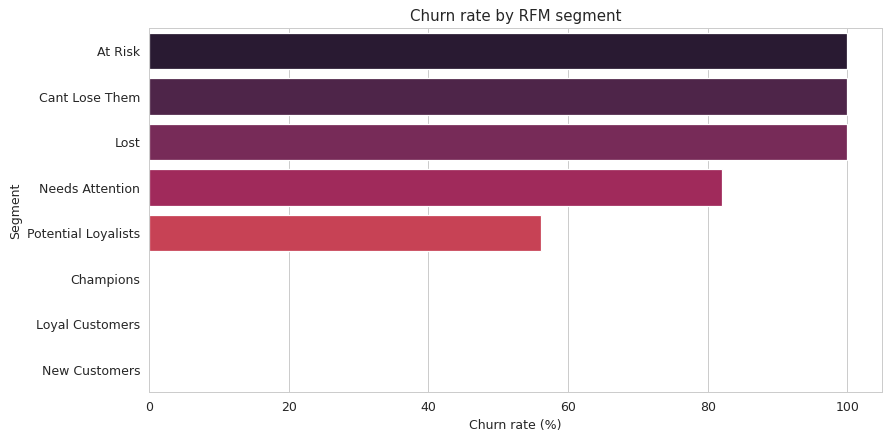

In [18]:
churn_by_segment = rfm.groupby('Segment')['churned'].agg(['mean', 'count'])
churn_by_segment['churn_rate_pct'] = (churn_by_segment['mean'] * 100).round(1)
churn_by_segment = churn_by_segment.sort_values('churn_rate_pct', ascending=False)
print(churn_by_segment[['count', 'churn_rate_pct']])

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=churn_by_segment['churn_rate_pct'], y=churn_by_segment.index, hue=churn_by_segment.index, palette='rocket', ax=ax, legend=False)
ax.set_title('Churn rate by RFM segment')
ax.set_xlabel('Churn rate (%)')
plt.tight_layout()
plt.show()


At Risk, Cant Lose Them, and Lost all sit at 100% churned, which makes sense since a low
recency score is required to land in any of those three segments in the first place, they're
built from the same 90-day signal. Needs Attention now sits at 51.7% churned, almost a coin
flip, which fits its definition better than the old version did: these are customers with
middling recency and low frequency, some are about to slide into At Risk and some aren't, so a
roughly even split is exactly what you'd expect from a genuine "keep an eye on them" group
rather than a churned-leaning catch-all.

## Part 3: Cohort Retention

### Step 1: Assign each customer to a cohort

A customer's cohort is the calendar month of their first order. Every customer stays in that
cohort for the life of the analysis, regardless of when they order after that.

In [21]:
df['order_month'] = df['InvoiceDate'].dt.to_period('M')
first_month = df.groupby('Customer ID')['order_month'].min().reset_index().rename(columns={'order_month': 'cohort_month'})
df_cohort = df.merge(first_month, on='Customer ID')
df_cohort['months_since_first'] = (df_cohort['order_month'] - df_cohort['cohort_month']).apply(lambda x: x.n)

cohort_counts = df_cohort.groupby(['cohort_month', 'months_since_first'])['Customer ID'].nunique().reset_index()
cohort_pivot = cohort_counts.pivot(index='cohort_month', columns='months_since_first', values='Customer ID')
cohort_sizes = cohort_pivot[0]

print("Cohort sizes (customers who made their first purchase that month):")
print(cohort_sizes)

Cohort sizes (customers who made their first purchase that month):
cohort_month
2009-12    952.0
2010-01    368.0
2010-02    375.0
2010-03    440.0
2010-04    294.0
2010-05    255.0
2010-06    267.0
2010-07    185.0
2010-08    163.0
2010-09    239.0
2010-10    375.0
2010-11    326.0
2010-12     76.0
2011-01     72.0
2011-02    125.0
2011-03    179.0
2011-04    106.0
2011-05    111.0
2011-06    108.0
2011-07    101.0
2011-08    107.0
2011-09    188.0
2011-10    221.0
2011-11    191.0
2011-12     28.0
Freq: M, Name: 0, dtype: float64


### Step 2: Convert counts into a retention percentage

Each row gets divided by its own cohort size, so every row starts at 100% in month 0, and the
following columns show what percentage of that original group was still ordering N months
later.

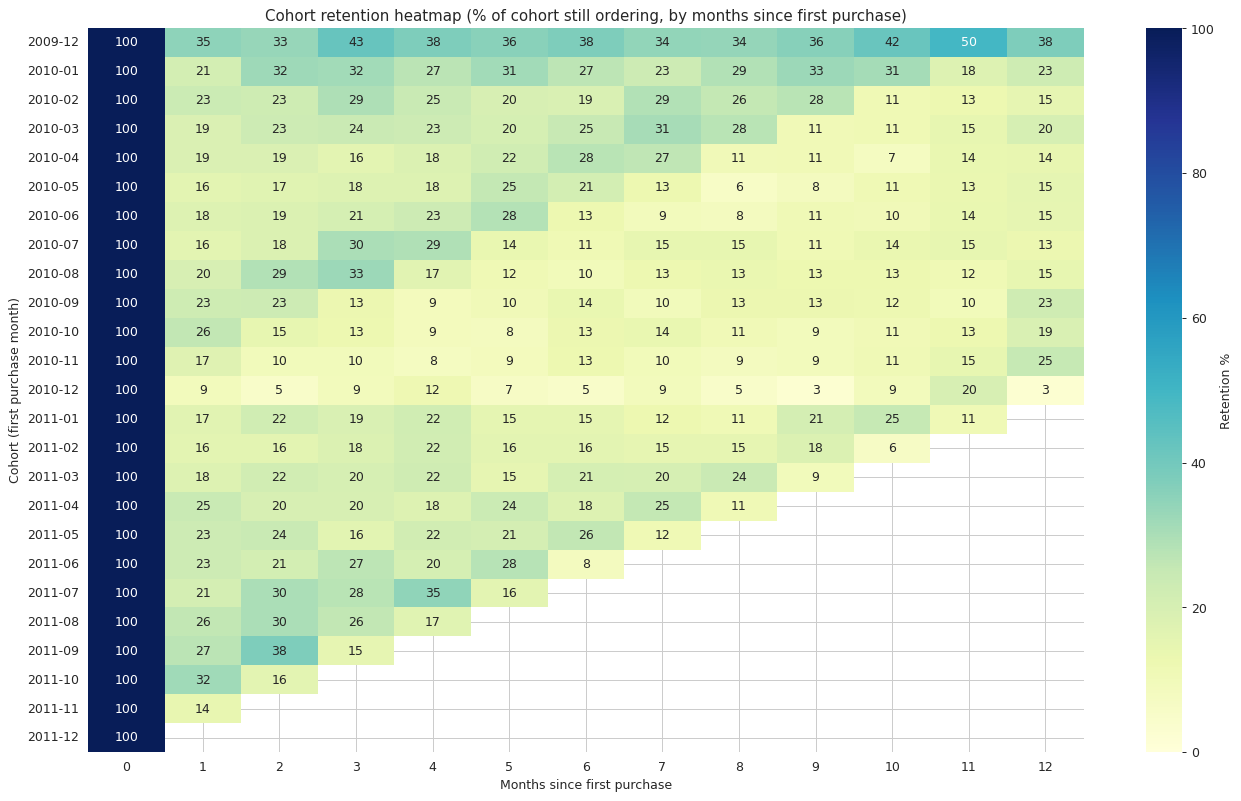

In [23]:
retention = cohort_pivot.divide(cohort_sizes, axis=0) * 100

fig, ax = plt.subplots(figsize=(15, 9))
sns.heatmap(retention.iloc[:, :13], annot=True, fmt='.0f', cmap='YlGnBu', ax=ax,
            cbar_kws={'label': 'Retention %'}, vmin=0, vmax=100)
ax.set_title('Cohort retention heatmap (% of cohort still ordering, by months since first purchase)')
ax.set_xlabel('Months since first purchase')
ax.set_ylabel('Cohort (first purchase month)')
plt.tight_layout()
plt.show()

### Step 3: What the heatmap says

The steepest drop happens immediately, month 0 to month 1, retention falls from 100% down to
somewhere in the 15 to 35% range for almost every cohort. That single jump is the biggest lever
in the whole business question: whatever's happening (or not happening) in a customer's first
month after their first order is doing more damage to retention than anything that happens
later. A second-order nudge, a follow-up email, a discount on a second purchase, aimed
specifically at the 30 to 60 day mark after someone's first order, is the highest-leverage single
recommendation this analysis can make.

There's also a cohort-quality story worth flagging. The very first cohort, December 2009,
retains noticeably better in later months (month 11 sits around 50%, well above most other
cohorts at the same point) than cohorts from mid-2010 onward. That could mean a few things: the
earliest customers may include a disproportionate number of the wholesale-style repeat buyers
flagged back in Phase 3, or it could be a genuine drop in how well the business retains newer
customers over time. Worth flagging as a "check next" item rather than a firm conclusion, since
telling those two explanations apart would need a closer look at which specific customers make
up that first cohort.

In [25]:
month1_retention = retention[1].dropna()
print("Average month-1 retention across all cohorts: {:.1f}%".format(month1_retention.mean()))
print("December 2009 cohort, month 1 retention: {:.1f}%".format(retention.loc['2009-12', 1]))
print("December 2009 cohort, month 11 retention: {:.1f}%".format(retention.loc['2009-12', 11]))

Average month-1 retention across all cohorts: 21.0%
December 2009 cohort, month 1 retention: 35.1%
December 2009 cohort, month 11 retention: 49.6%


## Step 4: Build the export for Power BI

One row per customer, combining RFM scores, segment, churn status, and cohort month, plus each
customer's primary country for the geography cut in the dashboard. This is the file Phase 5's
star schema will use as the customer dimension table.

In [27]:
# Weight by invoice, not by line item, a customer with one big multi-line order from one
# country and several small orders from another should be tagged by where most of their
# orders came from, not by whichever country happened to have the most line items.
invoice_country = df.groupby(['Customer ID', 'Invoice'])['Country'].first().reset_index()
primary_country = invoice_country.groupby('Customer ID')['Country'].agg(lambda x: x.value_counts().idxmax()).reset_index()

customer_segments = rfm.merge(primary_country, on='Customer ID')
customer_segments['cohort_month'] = customer_segments['first_order_date'].dt.to_period('M').astype(str)

customer_segments = customer_segments[[
    'Customer ID', 'Country', 'recency', 'frequency', 'monetary',
    'R_score', 'F_score', 'M_score', 'RFM_sum', 'Segment', 'churned',
    'first_order_date', 'last_order_date', 'cohort_month'
]]

customer_segments.to_csv('../datasets/derived/customer_segments.csv', index=False)
print("Saved customer_segments.csv,", customer_segments.shape[0], "rows")
customer_segments.head()


Saved customer_segments.csv, 5852 rows
  Customer ID         Country  recency  frequency  monetary  R_score  F_score  M_score  RFM_sum              Segment  churned    first_order_date     last_order_date cohort_month
0       12346  United Kingdom      326         12  77556.46        2        5        5       12              At Risk     True 2009-12-14 08:34:00 2011-01-18 10:01:00      2009-12
1       12347         Iceland        2          8   4921.53        5        4        5       14            Champions    False 2010-10-31 14:20:00 2011-12-07 15:52:00      2010-10
2       12348         Finland       75          5   1658.40        3        4        4       11  Potential Loyalists    False 2010-09-27 14:59:00 2011-09-25 13:13:00      2010-09
3       12349           Italy       19          3   3678.69        5        3        5       13      Loyal Customers    False 2010-04-29 13:20:00 2011-11-21 09:51:00      2010-04
4       12350          Norway      310          1    294.40       

## Summary going into Power BI Dashboard

- **RFM**: 8 named segments. Champions (22.0%) and Lost (24.8%) are the two largest groups.
  The gone-quiet segments (At Risk, Cant Lose Them, Lost) make up just under 40% of the customer
  base, and Needs Attention is now a proper mid-recency, low-frequency group at 51.7% churned
  rather than a churned-leaning leftover bucket.
- **Churn**: defined as 90+ days of inactivity, chosen from the actual gap-between-orders
  distribution rather than picked arbitrarily. 50.7% of customers are past that cutoff as of the
  snapshot date, though the most recent few months are still too soon to fully judge (censored).
  Orders placed heading into the winter, right before the seasonal slowdown, are the most likely
  to end up being someone's last.
- **Cohort retention**: the sharpest drop happens between month 0 and month 1 for every cohort,
  which is the single highest-leverage place to intervene. There's also a signal that the
  earliest cohort retains better long-term than more recent ones, worth investigating further
  with more time.
- **Output**: `customer_segments.csv`, one row per customer, ready to become the customer
  dimension table in the Power BI star schema.